## Box plot pour l'etude de cas des notes d'etudiants

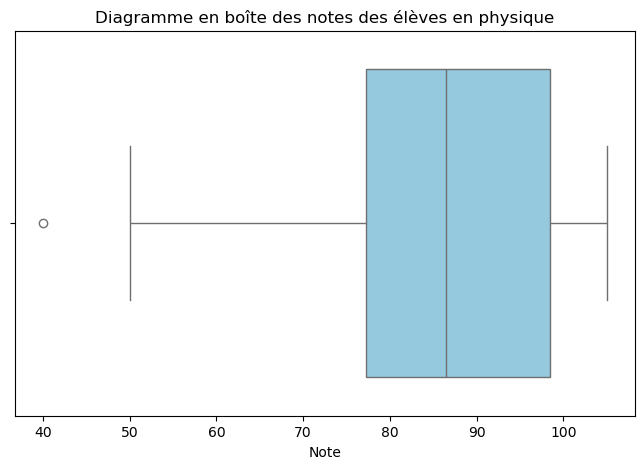

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Liste des notes des élèves
notes = [78, 82, 85, 88, 90, 92, 95, 98 ,
100, 102, 105, 100, 102, 75, 78, 
60, 54, 40, 85, 50]

# Créer le boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=notes, orient="h", color="skyblue")

# Ajouter un titre et une étiquette
plt.title("Diagramme en boîte des notes des élèves en physique")
plt.xlabel("Note")

# Afficher le graphique
# plt.show()

# sauvegarder comme fichier PNG
plt.savefig("boxplot1.png", dpi=300)

## Utilisation de la regle du livre

Q1 = 75, Médiane = 86.5, Q3 = 100
IQR = 25
Limites : [37.5, 137.5]
Outliers : []


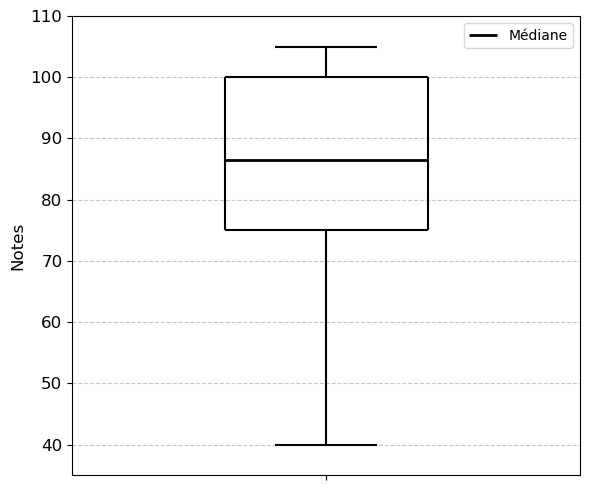

In [3]:
import matplotlib.pyplot as plt

# Données brutes
notes = [
    78, 82, 85, 88, 90, 92, 95, 98,
    100, 102, 105, 100, 102, 75, 78,
    60, 54, 40, 85, 50
]

# Trier les données
x = sorted(notes)
n = len(x)  # n = 20

# --- Calcul des quartiles selon VOTRE règle ---
def quartile_custom(data, k, n):
    """Calcule le k-ième quartile (k=1,2,3) selon la règle fournie."""
    rank = k * (n + 1) / 4
    if rank.is_integer():
        return data[int(rank) - 1]
    elif (rank * 2).is_integer():  # demi-fraction (ex: 5.5)
        low = int(rank // 1) - 1
        high = low + 1
        return (data[low] + data[high]) / 2
    else:
        idx = round(rank) - 1
        return data[idx]

Q1 = quartile_custom(x, 1, n)
Q2 = quartile_custom(x, 2, n)
Q3 = quartile_custom(x, 3, n)

# Bornes pour les outliers
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

min_val = min(x)
max_val = max(x)

# Détecter les outliers
outliers = [val for val in x if val < lower_fence or val > upper_fence]

print(f"Q1 = {Q1}, Médiane = {Q2}, Q3 = {Q3}")
print(f"IQR = {IQR}")
print(f"Limites : [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"Outliers : {outliers}")

# --- Tracer le boxplot personnalisé ---
fig, ax = plt.subplots(figsize=(6, 5))

# Position horizontale de la boîte
pos = 1
width = 0.4

# Coordonnées horizontales de la boîte
left = pos - width / 2
right = pos + width / 2

# 1. Boîte interquartile (Q1 à Q3)
ax.hlines(Q1, left, right, color='black', linewidth=1.5)
ax.hlines(Q3, left, right, color='black', linewidth=1.5)
ax.vlines(left, Q1, Q3, color='black', linewidth=1.5)   # ← Bord gauche
ax.vlines(right, Q1, Q3, color='black', linewidth=1.5)  # ← Bord droit

# 2. Médiane
ax.hlines(Q2, left, right, color='black', linewidth=2, label='Médiane')

# 3. Moustaches
ax.vlines(pos, min_val, Q1, color='black', linewidth=1.5)
ax.vlines(pos, Q3, max_val, color='black', linewidth=1.5)

# 4. Chapeaux (caps) des moustaches
cap_size = width / 2
ax.hlines(min_val, pos - cap_size/2, pos + cap_size/2, color='black', linewidth=1.5)
ax.hlines(max_val, pos - cap_size/2, pos + cap_size/2, color='black', linewidth=1.5)

# 5. Outliers (s'il y en a)
if outliers:
    ax.scatter([pos] * len(outliers), outliers, color='black', s=50, zorder=5, label='Outliers')

# Configuration du graphique
ax.set_xlim(0.5, 1.5)
ax.set_ylim(min_val - 5, max_val + 5)
ax.set_xticks([pos])
ax.set_xticklabels([''])
ax.set_ylabel('Notes',fontsize=12)
# ax.set_title('Diagramme en boîte (quartiles selon  règle)')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
if outliers or True:
    ax.legend()

plt.tight_layout()
# plt.show()
# sauvegarder comme fichier PNG
plt.savefig("boxplot.png", dpi=300)